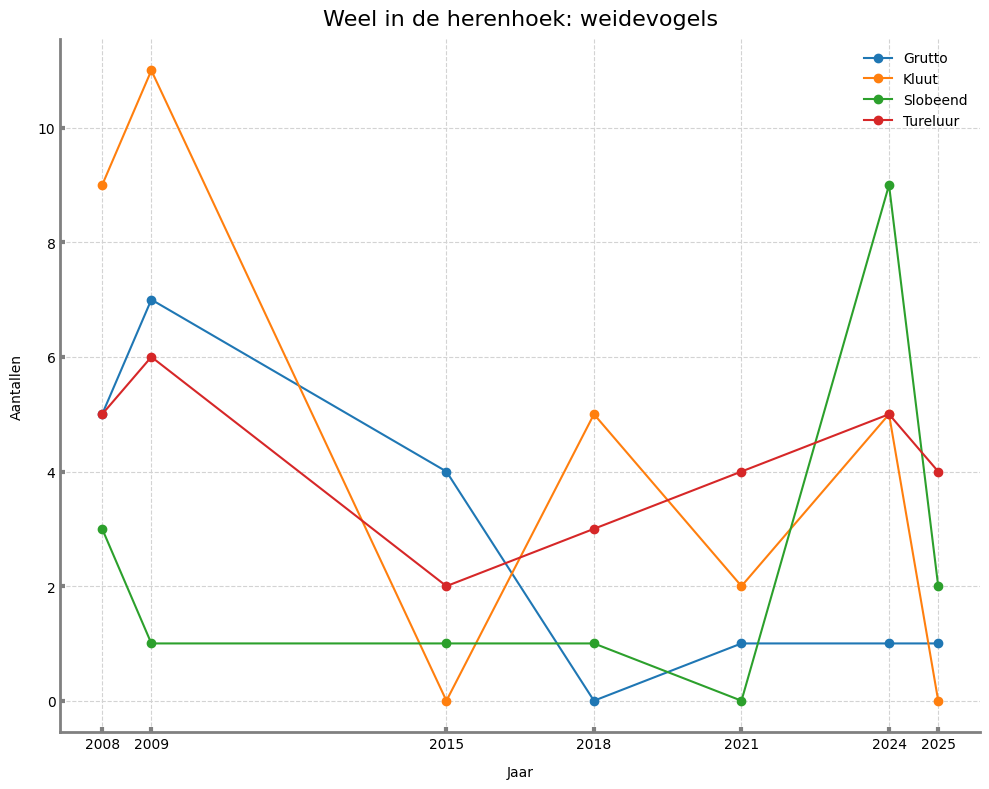

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pad = "/Users/hbraakmann/Desktop/QGIS_DATA/Heerenpolder/Avimap_totalen_territoria_Weel in de Heerenpolder.xlsx"
df = pd.read_excel(pad).fillna(0)


vogelsoorten = ["Grutto", "Kluut", "Tureluur", "Slobeend"]
weidevogels = df.loc[df["Soort"].isin(vogelsoorten)][["Soort", 2008, 2009, 2015, 2018, 2021, 2024, 2025]]

figure, ax = plt.subplots(figsize=(10,8))
                       
for _ , row in weidevogels.iterrows():
    jaren = weidevogels.columns[1:]
    aantallen = row[1:]
    ax.plot(jaren, aantallen, marker="o", label = row["Soort"], zorder = 3)

ax.set_title("Weel in de Herenhoek: Weidevogels".capitalize(), fontsize=16, pad=10)
ax.set_xlabel("Jaar", labelpad=10)
ax.set_ylabel("Aantallen", labelpad= 10)
ax.set_xticks(weidevogels.columns[1:].astype(int))
ax.grid(axis="both", linestyle="--", color="lightgrey", zorder=0)

ax.spines[["top", "right"]].set_visible(False)
#ax.spines[["left", "bottom"]].set_position(('outward', 10))
ax.spines[["left", "bottom"]].set_color("grey")
ax.spines[["left", "bottom"]].set_linewidth(2)
ax.tick_params(width=3, color="grey", direction="in")


ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [2]:
weidevogels

,Soort,2008,2009,2015,2018,2021,2024,2025
19,Grutto,5.0,7.0,4.0,0.0,1.0,1.0,1.0
26,Kluut,9.0,11.0,0.0,5.0,2.0,5.0,0.0
43,Slobeend,3.0,1.0,1.0,1.0,0.0,9.0,2.0
50,Tureluur,5.0,6.0,2.0,3.0,4.0,5.0,4.0


In [175]:
df["gemiddelde"] = df.iloc[:, 6:13].mean(axis=1).round(2)
top5 = df.nlargest(5, "gemiddelde").reset_index(drop=True)
top5

,Plotid,Plotnr,Plotnaam,Soort,Euring,IOC sort,2008,2009,2015,2018,2021,2024,2025,gemiddelde
0,34169,100519,Weel in de Heerenpolder,Grauwe Gans,1610,440,8.0,20.0,36.0,20.0,9.0,19.0,19.0,18.71
1,34169,100519,Weel in de Heerenpolder,Wilde Eend,1860,1160,15.0,17.0,18.0,12.0,10.0,22.0,5.0,14.14
2,34169,100519,Weel in de Heerenpolder,Graspieper,10110,11270,10.0,13.0,10.0,7.0,11.0,16.0,12.0,11.29
3,34169,100519,Weel in de Heerenpolder,Rietzanger,12430,9280,0.0,3.0,1.0,10.0,10.0,10.0,14.0,6.86
4,34169,100519,Weel in de Heerenpolder,Kleine Karekiet,12510,9310,0.0,1.0,5.0,13.0,4.0,13.0,11.0,6.71


In [176]:
bottom5 = df.loc[df["gemiddelde"]>0].nsmallest(5, "gemiddelde").reset_index(drop=True)
bottom5

,Plotid,Plotnr,Plotnaam,Soort,Euring,IOC sort,2008,2009,2015,2018,2021,2024,2025,gemiddelde
0,34169,100519,Weel in de Heerenpolder,Brandgans,1670,250,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.14
1,34169,100519,Weel in de Heerenpolder,Dodaars,70,2940,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.14
2,34169,100519,Weel in de Heerenpolder,Holenduif,6680,2450,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.14
3,34169,100519,Weel in de Heerenpolder,Kuifeend,2030,1380,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.14
4,34169,100519,Weel in de Heerenpolder,Putter,16530,11680,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.14


In [59]:
### Dictionary to the resque!

dumb = pd.DataFrame({
    "Soort": df["Soort"],
    "Totaal": df.iloc[:,6:13].sum(axis=1).astype("Int64")
}).sort_values(by="Totaal", ascending=False)

df_final = pd.merge(df, dumb, on="Soort")
df_final.sort_values(by="Totaal", ascending=False)

,Plotid,Plotnr,Plotnaam,Soort,Euring,IOC sort,2008,2009,2015,2018,2021,2024,2025,Totaal
16,34169,100519,Weel in de Heerenpolder,Grauwe Gans,1610,440,8.0,20.0,36.0,20.0,9.0,19.0,19.0,131
55,34169,100519,Weel in de Heerenpolder,Wilde Eend,1860,1160,15.0,17.0,18.0,12.0,10.0,22.0,5.0,99
15,34169,100519,Weel in de Heerenpolder,Graspieper,10110,11270,10.0,13.0,10.0,7.0,11.0,16.0,12.0,79
38,34169,100519,Weel in de Heerenpolder,Rietzanger,12430,9280,0.0,3.0,1.0,10.0,10.0,10.0,14.0,48
32,34169,100519,Weel in de Heerenpolder,Meerkoet,4290,2770,5.0,5.0,4.0,6.0,6.0,11.0,10.0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,34169,100519,Weel in de Heerenpolder,Cetti's Zanger,12200,8990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,34169,100519,Weel in de Heerenpolder,Buizerd,2870,6780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,34169,100519,Weel in de Heerenpolder,Bosruiter,5540,4260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,34169,100519,Weel in de Heerenpolder,Boerenzwaluw,9920,8910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
